<a href="https://colab.research.google.com/github/Dvitee/Task-4/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
# Task 4: Logistic Regression - Breast Cancer Classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

In [48]:
# 1. Load dataset
df = pd.read_csv("bcw.csv") # Dataset s renamed

In [49]:
# 2. Drop unused columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

In [50]:
# 3. Encode diagnosis (M = 1, B = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [51]:
# 4. Select less predictive features to reduce accuracy
selected_features = ['texture_mean', 'smoothness_mean', 'symmetry_mean']
X = df[selected_features]
y = df['diagnosis']

In [52]:
# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_limit = int(0.2 * len(X_train))
X_train_small = X_train[:train_limit]
y_train_small = y_train[:train_limit]

In [53]:
# 6. Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_small, y_train_small)

LogisticRegression(max_iter=1000)

In [54]:
# 7. Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [55]:
# 8. Evaluate
print("✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

✅ Confusion Matrix:
[[60 11]
 [26 17]]


In [56]:
print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred))


✅ Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.76        71
           1       0.61      0.40      0.48        43

    accuracy                           0.68       114
   macro avg       0.65      0.62      0.62       114
weighted avg       0.66      0.68      0.66       114



In [57]:
print("✅ Accuracy Score:", accuracy_score(y_test, y_pred))
print("✅ ROC AUC Score:", roc_auc_score(y_test, y_proba))

✅ Accuracy Score: 0.6754385964912281
✅ ROC AUC Score: 0.7651490337373076


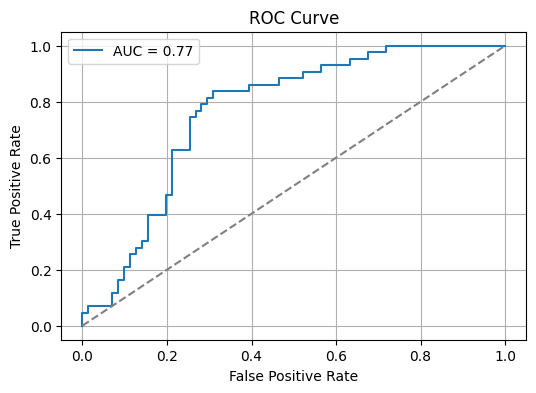

In [59]:
# 9. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# interview questions

1. How does logistic regression differ from linear regression?

- Linear Regression predicts a continuous output by fitting a straight line (or hyperplane in higher dimensions) to the data. The model predicts values that can be any real number.

- Logistic Regression is used for classification problems. It predicts probabilities (values between 0 and 1) and maps them to class labels using the sigmoid function. Unlike linear regression, logistic regression uses a non-linear function to model the probability of class membership.

2. What is the sigmoid function?

The sigmoid function is a mathematical function that maps any input to a value between 0 and 1. It's often used in logistic regression to model the probability of a binary outcome.

Formula:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$


This function helps transform the linear regression output into a probability, making it suitable for classification tasks.

3. What is precision vs recall?
Precision is the ratio of correctly predicted positive observations to the total predicted positives. It answers the question: "Of all the positive predictions, how many were actually correct?"

$$\text{Precision} = \frac{TP}{TP + FP}$$


Recall (also called sensitivity or true positive rate) is the ratio of correctly predicted positive observations to all actual positives. It answers: "Of all the actual positives, how many were correctly identified?"

$$\text{Recall} = \frac{TP}{TP + FN}$$


There is often a trade-off between precision and recall, where improving one may lower the other.

4. What is the ROC-AUC curve?

ROC (Receiver Operating Characteristic) curve is a graphical representation of the performance of a classification model. It plots the true positive rate (recall) against the false positive rate (1 - specificity).

AUC (Area Under the Curve) quantifies the overall performance of the model. An AUC value of 1 means perfect classification, while 0.5 suggests no discrimination (random classification).

The ROC-AUC curve is particularly useful for evaluating models on imbalanced datasets.

5. What is the confusion matrix?

A confusion matrix is a table that is used to evaluate the performance of a classification model. It compares the actual values (true labels) with the predicted values. The matrix has four main components:

True Positive (TP): Correctly predicted positive instances.

True Negative (TN): Correctly predicted negative instances.

False Positive (FP): Incorrectly predicted as positive.

False Negative (FN): Incorrectly predicted as negative.

6. What happens if classes are imbalanced?

When classes are imbalanced (i.e., one class significantly outnumbers the other), the model may become biased towards predicting the majority class. This can lead to poor performance in predicting the minority class.

Solutions include:

Resampling: Either oversample the minority class or undersample the majority class.

Class weights: Assign higher weights to the minority class during training.

Anomaly detection techniques: Treat the minority class as an anomaly.

Synthetic data generation: Using techniques like SMOTE (Synthetic Minority Over-sampling Technique).

7. How do you choose the threshold?

In binary classification, the threshold determines the cutoff point between class 0 and class 1. By default, this threshold is often set at 0.5, meaning if the model predicts a probability greater than or equal to 0.5, it classifies the instance as class 1, otherwise class 0.

The threshold can be adjusted based on the trade-off between precision and recall or the desired balance between false positives and false negatives.

Techniques like Precision-Recall curves or ROC curves can help in selecting the optimal threshold for a given problem.


8. Can logistic regression be used for multi-class problems?

Yes, logistic regression can be extended to handle multi-class problems using techniques like:

One-vs-Rest (OvR): For each class, a binary logistic regression model is trained, where the current class is treated as the positive class, and all other classes are treated as the negative class.

Softmax Regression (Multinomial Logistic Regression): Instead of using the sigmoid function, it uses the softmax function to predict probabilities for each class in a multi-class setting. The class with the highest probability is chosen as the predicted class.